In [3]:
# === PATHWAY SETTINGS ===
from helper import calculations_path

material = [
    "diamond",
    "NV_center"
    ]

size = [
    "1x1x1", 
    "2x2x2", 
    "3x3x3"
    ] 

material = "NV_center"
#material = "diamond"

#size = "1x1x1"
#size = "2x2x2"
size = "3x3x3"


print(calculations_path)

PATH = calculations_path / f"{material}/{size}"


print("Using results folder:", PATH)


/Users/famkepotze/Desktop/3S/DFT_folder/results/calculations
Using results folder: /Users/famkepotze/Desktop/3S/DFT_folder/results/calculations/NV_center/3x3x3


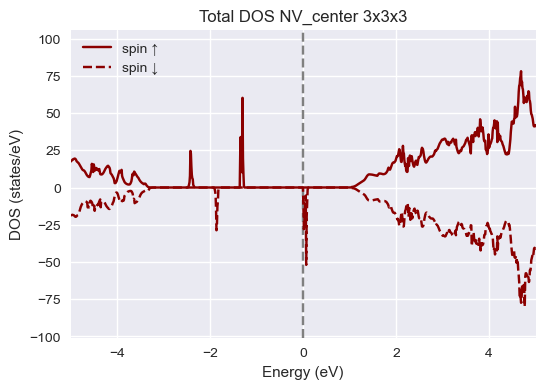

In [4]:
#requirements
import os
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")


if material == "NV_center":

    dos_file = os.path.join(PATH, f"{material}_{size}.dos")

    if os.path.exists(dos_file):
        # Read header to get Fermi level
        
        with open(dos_file) as f:
            header = f.readline()
        fermi = float(header.split("EFermi")[1].split("eV")[0].replace("=", "").strip())

        data = np.loadtxt(dos_file, skiprows=1)
        E = data[:,0] - fermi
        DOS_up = data[:,1]
        DOS_down = data[:,2]

        plt.figure(figsize=(6,4))
        plt.axvline(0, color="gray", linestyle="--")
        plt.plot(E, DOS_up,  color="darkred",  label="spin ↑")
        plt.plot(E, -DOS_down, color="darkred", linestyle="--", label="spin ↓")
        plt.xlim(-5, 5)
        plt.title(f"Total DOS {material} {size}")
        plt.xlabel("Energy (eV)")
        plt.ylabel("DOS (states/eV)")
        plt.legend()
        plt.show()

    else:
        print("DOS file not found:", dos_file)
    
elif material == "diamond":

    dos_file = os.path.join(PATH, f"{material}_{size}.dos")

    if os.path.exists(dos_file):
    # Read header to get Fermi level
        with open(dos_file) as f:
            header = f.readline()
        try:
            fermi = float(header.split("EFermi")[1].split("eV")[0].replace("=", "").strip())
        except Exception:
            fermi = 0.0
            print("⚠ Could not parse EFermi from header, using 0.0 eV")

        data = np.loadtxt(dos_file, skiprows=1)
        energy = data[:, 0] - fermi   # align to EF = 0
        dos = data[:, 1]

        plt.figure(figsize=(6,4))
        plt.plot(energy, dos, color="darkred")
        plt.axvline(0, color="gray", linestyle="--")
        plt.xlim(-5, 8)             # match PDOS range
        plt.xlabel("Energy (eV)")
        plt.ylabel("DOS (states/eV)")
        plt.title(f"Total DOS of {material} {size}")
        plt.show()

    else:
        print("DOS file not found:", dos_file)

/Users/famkepotze/Desktop/3S/DFT_folder/results/calculations


/var/folders/xf/gwpgk5dx3d732nlgkcmdjjl40000gn/T/ipykernel_1158/4019160919.py:97: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


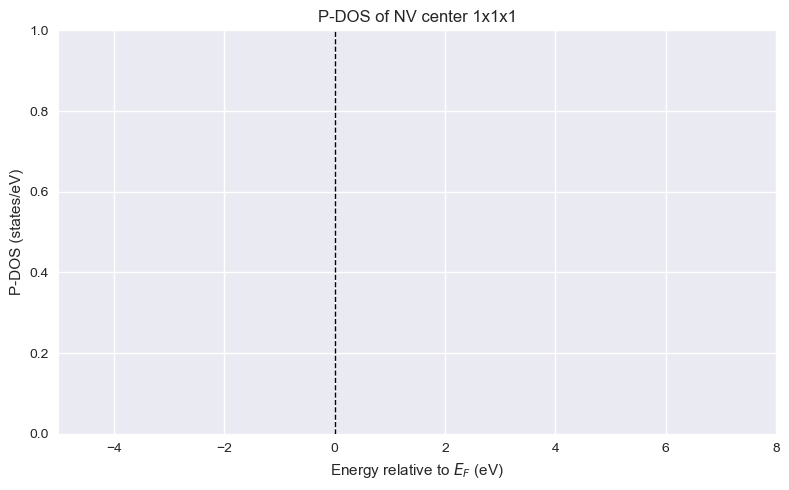

In [5]:
# PDOS NV center 1x1x1, N, C1, C2, C3


material = "diamond"

size = "1x1x1"

print(calculations_path)

PATH = calculations_path / f"{material}/{size}"

import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# --------------------------------------------------
# Path containing PDOS files
# --------------------------------------------------

# --------------------------------------------------
# Mapping atom -> label
# --------------------------------------------------
labels = {
    "atm#1(N)": "N",
    "atm#2(C)": "C1",
    "atm#4(C)": "C2",
    "atm#6(C)": "C3",
}

# --------------------------------------------------
# Collect PDOS files
# --------------------------------------------------
pdos_files = sorted(glob.glob(os.path.join(PATH, "pdos.pdos_atm*")))

keep = []

for f in pdos_files:

    name = os.path.basename(f)

    # keep only p orbitals
    if "wfc#2(p)" not in name:
        continue

    # keep only selected atoms
    for atom_id in labels:
        if atom_id in name:
            keep.append((f, labels[atom_id]))
            break

# --------------------------------------------------
# Plot
# --------------------------------------------------
plt.figure(figsize=(8,5))

for f, short_label in keep:

    data = np.loadtxt(f)

    E = data[:,0] - fermi

    # QE spin-polarized PDOS format
    up = data[:,3]
    down = data[:,4]

    # spin up
    line, = plt.plot(
        E,
        up,
        linewidth=2,
        label=f"{short_label} ↑"
    )

    # spin down
    plt.plot(
        E,
        -down,
        "--",
        linewidth=2,
        color=line.get_color(),
        label=f"{short_label} ↓"
    )

# --------------------------------------------------
# Formatting
# --------------------------------------------------
plt.axvline(0, color="black", linestyle="--", linewidth=1)

plt.xlim(-5, 8)

plt.xlabel("Energy relative to $E_F$ (eV)")
plt.ylabel("P-DOS (states/eV)")

plt.title("P-DOS of NV center 1x1x1")

plt.legend()
plt.tight_layout()

plt.show()

/var/folders/xf/gwpgk5dx3d732nlgkcmdjjl40000gn/T/ipykernel_1158/3858066741.py:93: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


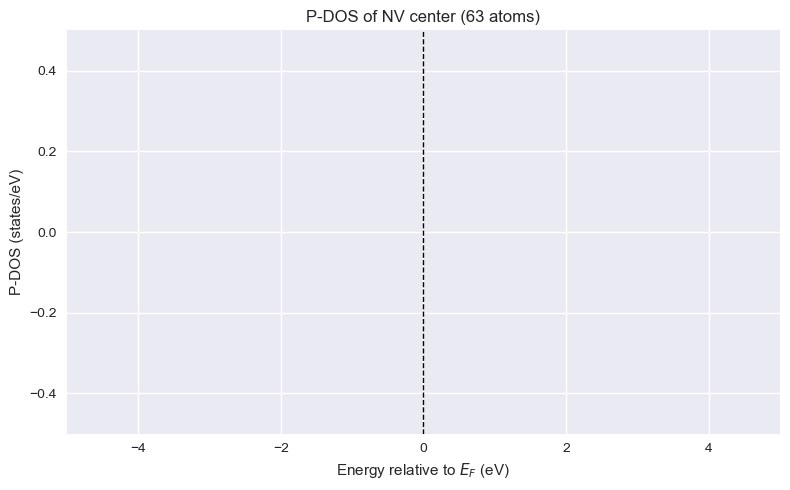

In [6]:
## PDOS NV center 2x2x2 N, C1, C2, C3

import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# --------------------------------------------------
# Path containing PDOS files
# --------------------------------------------------
PATH = "results"

# --------------------------------------------------
# Mapping atom -> label
# --------------------------------------------------
labels = {
    "atm#57(N)": "N",
    "atm#58(C)": "C1",
    "atm#60(C)": "C2",
    "atm#62(C)": "C3",
}




# --------------------------------------------------
# Collect PDOS files
# --------------------------------------------------
pdos_files = sorted(glob.glob(os.path.join(PATH, "pdos.pdos_atm*")))

keep = []

for f in pdos_files:

    name = os.path.basename(f)

    # keep only p orbitals
    if "wfc#2(p)" not in name:
        continue

    # keep only selected atoms
    for atom_id in labels:
        if atom_id in name:
            keep.append((f, labels[atom_id]))
            break

# --------------------------------------------------
# Plot
# --------------------------------------------------
plt.figure(figsize=(8,5))

for f, short_label in keep:

    data = np.loadtxt(f)

    E = data[:,0] - fermi

    # QE spin-polarized PDOS format
    up = data[:,3]
    down = data[:,4]

    # spin up
    line, = plt.plot(
        E,
        up,
        linewidth=2,
        label=f"{short_label} ↑"
    )

    # spin down
    plt.plot(
        E,
        -down,
        "--",
        linewidth=2,
        color=line.get_color(),
        label=f"{short_label} ↓"
    )

# --------------------------------------------------
# Formatting
# --------------------------------------------------
plt.axvline(0, color="black", linestyle="--", linewidth=1)

plt.xlim(-5, 5)
plt.ylim(-0.5, 0.5)

plt.xlabel("Energy relative to $E_F$ (eV)")
plt.ylabel("P-DOS (states/eV)")

plt.title("P-DOS of NV center (63 atoms)")

plt.legend()
plt.tight_layout()

plt.show()